In [1]:
# ------------------------------------------------------------
# Step 0 : build synthetic data that mimics BEBRM feature set
# ------------------------------------------------------------
import numpy as np
import pandas as pd

np.random.seed(7)
N_PLAYERS = 400                     # number of synthetic players

data = {
    # ---------- Hustle ----------
    "CONTESTED_SHOTS"      : np.random.poisson(55,  N_PLAYERS),
    "DEFLECTIONS"          : np.random.poisson(38,  N_PLAYERS),
    "CHARGES_DRAWN"        : np.random.poisson( 4,  N_PLAYERS),
    "SCREEN_ASSISTS"       : np.random.poisson(85,  N_PLAYERS),
    "LOOSE_BALLS_RECOVERED": np.random.poisson(12,  N_PLAYERS),
    "BOX_OUTS"             : np.random.poisson(65,  N_PLAYERS),
    
    # ---------- Matchups ----------
    "MATCHUP_EFG_DIFF"     : np.random.normal(-0.015, 0.020, N_PLAYERS),  # ↓ better
    "HELP_BLOCK_RATE"      : np.random.beta(2, 18, N_PLAYERS),            # %
    
    # ---------- Shot‑chart spacing ----------
    "SPACING_IMPACT"       : np.random.normal(0.0, 0.03,  N_PLAYERS),     # Δ team eFG
       
    # ---------- Synergy play‑types ----------
    "ISO_PPP"              : np.random.normal(0.96, 0.07,  N_PLAYERS),
    "PNR_BH_PPP"           : np.random.normal(1.00, 0.06,  N_PLAYERS),
    "SPOT_UP_PPP"          : np.random.normal(1.07, 0.05,  N_PLAYERS),
    
    # ---------- On/Off ----------
    "NET_RTG_DIFF"         : np.random.normal(0.0, 2.5,   N_PLAYERS),     # on‑off net rating
}

df = pd.DataFrame(data)

# --- Construct a hidden “true impact” target for demonstration ---
coef = np.array([0.012, 0.018, 0.08, 0.010, 0.045, 0.009,
                 -220, 15, 250,      # matchup & spacing
                 4.0, 3.2, 3.8,      # synergy
                 0.35])              # on/off
df["TRUE_IMPACT"] = df.values @ coef + np.random.normal(0, 1.8, N_PLAYERS)

df.head()


,CONTESTED_SHOTS,DEFLECTIONS,CHARGES_DRAWN,SCREEN_ASSISTS,LOOSE_BALLS_RECOVERED,BOX_OUTS,MATCHUP_EFG_DIFF,HELP_BLOCK_RATE,SPACING_IMPACT,ISO_PPP,PNR_BH_PPP,SPOT_UP_PPP,NET_RTG_DIFF,TRUE_IMPACT
0,42,42,4,79,12,53,-0.003364,0.005886,-0.030090,0.948373,0.918027,1.068471,1.128503,11.557689
1,54,33,1,105,12,60,-0.019801,0.107749,-0.026606,0.902402,0.889964,1.097477,1.382974,16.668032
2,55,39,3,92,17,67,-0.032997,0.111611,0.004918,0.955390,0.928272,1.035041,1.939420,24.575850
3,50,33,3,75,10,60,0.013268,0.209065,0.066965,0.973229,1.032914,1.075819,-5.950252,29.375380
4,59,33,3,83,12,66,-0.043043,0.113846,-0.036702,0.837545,0.835006,1.055197,-2.205370,15.099774


In [2]:
# ------------------------------------------------------------
# Step 1.ii :  fit baseline BayesianRidge  +  one‑pass residual Ridge
# ------------------------------------------------------------
from sklearn.linear_model import BayesianRidge, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import statsmodels.api as sm
import numpy as np
import pandas as pd

X = df.drop(columns=["TRUE_IMPACT"])
y = df["TRUE_IMPACT"]

# ---------- (a) Bayesian Ridge = baseline prior ----------
bayes_pipe = make_pipeline(StandardScaler(), BayesianRidge())
bayes_pipe.fit(X, y)

# save baseline scores
df["BASELINE_SCORE"] = bayes_pipe.predict(X)

# summary‑like table of posterior means & std
br_model = bayes_pipe.named_steps["bayesianridge"]
summary_tbl = pd.DataFrame({
    "feature"  : X.columns,
    "coef_mean": br_model.coef_,
    "coef_std" : np.sqrt(np.diag(br_model.sigma_))
})
print(summary_tbl.round(4))

# ---------- (b) One‑pass residual ridge (offensive side demo) ----------
residual = y - df["BASELINE_SCORE"]
ridge_pipe = make_pipeline(StandardScaler(), Ridge(alpha=50.0))
ridge_pipe.fit(X, residual)

df["FINAL_SCORE"] = df["BASELINE_SCORE"] + ridge_pipe.predict(X)

print("\nOne‑pass residual Ridge coefficients:")
for f,c in zip(X.columns, ridge_pipe.named_steps["ridge"].coef_):
    print(f"{f:25s}: {c: .4f}")


                  feature  coef_mean  coef_std
0         CONTESTED_SHOTS     0.1637    0.0881
1             DEFLECTIONS    -0.0049    0.0885
2           CHARGES_DRAWN     0.1120    0.0894
3          SCREEN_ASSISTS     0.1119    0.0887
4   LOOSE_BALLS_RECOVERED     0.0725    0.0883
5                BOX_OUTS     0.0362    0.0890
6        MATCHUP_EFG_DIFF    -4.2156    0.0887
7         HELP_BLOCK_RATE     0.9331    0.0898
8          SPACING_IMPACT     7.7818    0.0882
9                 ISO_PPP     0.1895    0.0883
10             PNR_BH_PPP     0.2367    0.0882
11            SPOT_UP_PPP     0.1422    0.0882
12           NET_RTG_DIFF     1.0322    0.0885

One‑pass residual Ridge coefficients:
CONTESTED_SHOTS          :  0.0003
DEFLECTIONS              : -0.0002
CHARGES_DRAWN            :  0.0005
SCREEN_ASSISTS           : -0.0001
LOOSE_BALLS_RECOVERED    : -0.0003
BOX_OUTS                 : -0.0007
MATCHUP_EFG_DIFF         : -0.0046
HELP_BLOCK_RATE          :  0.0015
SPACING_IMPACT         

In [3]:
# ------------------------------------------------------------
# Step 1.iii : test hypothesis on SCREEN_ASSISTS
# ------------------------------------------------------------
X_const = sm.add_constant(df[["SCREEN_ASSISTS"]])
ols_sa   = sm.OLS(df["FINAL_SCORE"], X_const).fit()

print(ols_sa.summary())   # classic regression table

p_val = ols_sa.pvalues["SCREEN_ASSISTS"]
coef  = ols_sa.params ["SCREEN_ASSISTS"]
alpha = 0.05
if (coef > 0) and (p_val < alpha):
    conclusion = "Reject H0: positive & significant."
else:
    conclusion = "Fail to reject H0."
print("\nConclusion on RQ :", conclusion)


                            OLS Regression Results                            
Dep. Variable:            FINAL_SCORE   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.3373
Date:                Tue, 15 Apr 2025   Prob (F-statistic):              0.562
Time:                        11:27:29   Log-Likelihood:                -1447.8
No. Observations:                 400   AIC:                             2900.
Df Residuals:                     398   BIC:                             2908.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             16.5315      4.001      4.

In [4]:
# ------------------------------------------------------------
# Step 1.iv : 5‑fold CV on BayesianRidge prior
# ------------------------------------------------------------
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, make_scorer

kf          = KFold(n_splits=5, shuffle=True, random_state=7)
rmse_metric = make_scorer(mean_squared_error, squared=False)
cv_rmse     = cross_val_score(bayes_pipe, X, y, cv=kf, scoring=rmse_metric)

print("5‑fold RMSE:", np.round(cv_rmse, 3))
print("Mean RMSE  :", cv_rmse.mean().round(3))
print("Std  RMSE  :", cv_rmse.std().round(3))


5‑fold RMSE: [1.753 1.741 1.995 1.621 1.83 ]
Mean RMSE  : 1.788
Std  RMSE  : 0.123


D:\Anaconda\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


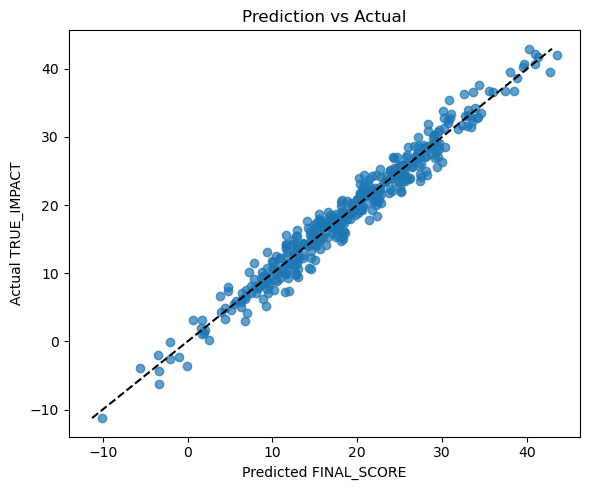

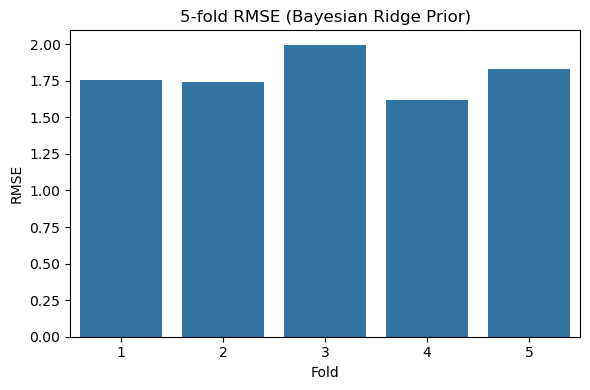

In [5]:
# ------------------------------------------------------------
# Step 1.v : graphics – Pred vs Actual  &  CV‑RMSE bar
# ------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# (a) Predicted vs Actual (final score)
plt.figure(figsize=(6,5))
plt.scatter(df["FINAL_SCORE"], y, alpha=.7)
lims = [y.min(), y.max()]
plt.plot(lims, lims, 'k--')
plt.xlabel("Predicted FINAL_SCORE")
plt.ylabel("Actual TRUE_IMPACT")
plt.title("Prediction vs Actual")
plt.tight_layout()
plt.show()

# (b) CV RMSE distribution
plt.figure(figsize=(6,4))
sns.barplot(x=np.arange(1,6), y=cv_rmse)
plt.ylabel("RMSE")
plt.xlabel("Fold")
plt.title("5‑fold RMSE (Bayesian Ridge Prior)")
plt.tight_layout()
plt.show()
